<a href="https://colab.research.google.com/github/sdsharma1469/RobotLearning_project2/blob/main/ECEN524_Project2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os, glob

VIDEO_DIR = "/content/drive/MyDrive/Video_Demos"  # change me

videos = []
for ext in ("*.mp4", "*.mov", "*.mkv", "*.avi"):
    videos += glob.glob(os.path.join(VIDEO_DIR, "**", ext), recursive=True)

print("Found videos:", len(videos))
videos[:5]

Found videos: 10


['/content/drive/MyDrive/Video_Demos/Copy of data6.mov',
 '/content/drive/MyDrive/Video_Demos/Copy of data10.mov',
 '/content/drive/MyDrive/Video_Demos/Copy of data1.mov',
 '/content/drive/MyDrive/Video_Demos/Copy of data9.mov',
 '/content/drive/MyDrive/Video_Demos/Copy of data5.mov']

In [ ]:
!pip -q install mediapipe==0.10.32 opencv-python pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 46.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 8.4 MB/s eta 0:00:00


# FIRST WE GET THE HAND POSITIONS

In [ ]:
import cv2, os
import pandas as pd
import numpy as np

import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

In [ ]:
OUT_DIR = "/content/hand_state_out"
os.makedirs(OUT_DIR, exist_ok=True)

MODEL_PATH = os.path.join(OUT_DIR, "hand_landmarker.task")
if not os.path.exists(MODEL_PATH):
    import urllib.request
    url = "https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task"
    urllib.request.urlretrieve(url, MODEL_PATH)

base_options = python.BaseOptions(model_asset_path=MODEL_PATH)
options = vision.HandLandmarkerOptions(base_options=base_options, num_hands=2)
detector = vision.HandLandmarker.create_from_options(options)

In [ ]:
VIDEO_DIR = "/content/drive/MyDrive/Video_Demos"  # change
videos = []
for ext in ("*.mp4", "*.mov", "*.mkv", "*.avi"):
    videos += glob.glob(os.path.join(VIDEO_DIR, "**", ext), recursive=True)

print("Found:", len(videos))
print(videos[:3])

Found: 10
['/content/drive/MyDrive/Video_Demos/Copy of data6.mov', '/content/drive/MyDrive/Video_Demos/Copy of data10.mov', '/content/drive/MyDrive/Video_Demos/Copy of data1.mov']


In [ ]:
def safe_name(path):
    base = os.path.splitext(os.path.basename(path))[0]
    return re.sub(r"[^A-Za-z0-9_\-]+", "_", base)

def extract_hand_open_closed(video_path, out_dir=OUT_DIR, smooth_window=7):
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
    W   = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    H   = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    # ---------- Pass 1: collect per-frame landmarks we need ----------
    rows = []
    frame_idx = 0
    while True:
        ok, frame_bgr = cap.read()
        if not ok:
            break
        frame_idx += 1

        frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame_rgb)
        result = detector.detect(mp_image)

        # Save needed landmarks (wrist 0, thumb tip 4, index tip 8) for each detected hand
        if result.hand_landmarks:
            for h_i, hand in enumerate(result.hand_landmarks):
                # guard: ensure 21 landmarks
                if len(hand) < 9:
                    continue
                wrist = hand[0]
                thumb = hand[4]
                index = hand[8]
                pinch = np.sqrt((thumb.x - index.x)**2 + (thumb.y - index.y)**2)

                rows.append({
                    "video": os.path.basename(video_path),
                    "frame": frame_idx,
                    "time_s": frame_idx / fps,
                    "hand": h_i,
                    "wrist_x": wrist.x, "wrist_y": wrist.y, "wrist_z": wrist.z,
                    "pinch": float(pinch),
                })

    cap.release()

    df = pd.DataFrame(rows)
    if df.empty:
        # still write an empty CSV for consistency
        out_csv = os.path.join(out_dir, f"{safe_name(video_path)}_hand_state.csv")
        df.to_csv(out_csv, index=False)
        return out_csv, df

    # Choose the "active" hand = appears in the most frames (you said 1 hand is used)
    counts = df.groupby("hand")["frame"].nunique().sort_values(ascending=False)
    active_hand = int(counts.index[0])
    df = df[df["hand"] == active_hand].copy()

    # ---------- Smooth pinch ----------
    df = df.sort_values("frame")
    df["pinch_smooth"] = df["pinch"].rolling(window=smooth_window, center=True, min_periods=1).mean()

    # ---------- Thresholds (auto) + hysteresis ----------
    low  = df["pinch_smooth"].quantile(0.20)  # closed-ish
    high = df["pinch_smooth"].quantile(0.60)  # open-ish

    state = 0  # 0=open, 1=closed
    states = []
    for x in df["pinch_smooth"].to_numpy():
        if state == 0 and x < low:
            state = 1
        elif state == 1 and x > high:
            state = 0
        states.append(state)

    df["hand_state"] = states
    df["hand_state_str"] = df["hand_state"].map({0: "OPEN", 1: "CLOSED"})

    # Add pixel wrist coords (useful for debugging/overlay)
    df["wrist_px"] = (df["wrist_x"] * W).round().astype(int)
    df["wrist_py"] = (df["wrist_y"] * H).round().astype(int)

    out_csv = os.path.join(out_dir, f"{safe_name(video_path)}_hand_state.csv")
    df.to_csv(out_csv, index=False)
    return out_csv, df

In [ ]:
import re
all_csvs = []
for vp in videos:
    out_csv, _ = extract_hand_open_closed(vp)
    all_csvs.append(out_csv)

print("Wrote CSVs:", len(all_csvs))
print(all_csvs[:3])

Wrote CSVs: 10
['/content/hand_state_out/Copy_of_data6_hand_state.csv', '/content/hand_state_out/Copy_of_data10_hand_state.csv', '/content/hand_state_out/Copy_of_data1_hand_state.csv']


In [ ]:
import os

def annotate_video_with_state(video_path, state_csv, out_dir=OUT_DIR):
    import pandas as pd, cv2
    df = pd.read_csv(state_csv)
    if df.empty:
        raise ValueError(f"State CSV is empty (no hand detected): {state_csv}")

    m = df.set_index("frame")[["hand_state_str", "wrist_px", "wrist_py"]].to_dict("index")

    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
    W   = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    H   = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    base = safe_name(video_path)
    out_mp4  = os.path.join(out_dir, f"{base}_annot.mp4")
    out_h264 = os.path.join(out_dir, f"{base}_annot_h264.mp4")

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(out_mp4, fourcc, fps, (W, H))

    frame_idx = 0
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        frame_idx += 1

        info = m.get(frame_idx, None)
        if info is not None:
            s = info["hand_state_str"]
            x = int(info["wrist_px"])
            y = int(info["wrist_py"])
            cv2.circle(frame, (x, y), 8, (0, 255, 0), -1)
            cv2.putText(frame, f"{s}  wrist=({x},{y})  frame={frame_idx}",
                        (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255,255,255), 2)

        writer.write(frame)

    cap.release()
    writer.release()

    os.system(
        f'ffmpeg -y -i "{out_mp4}" -c:v libx264 -pix_fmt yuv420p -movflags +faststart "{out_h264}" > /dev/null 2>&1'
    )
    return out_h264

In [ ]:
annotated_videos = []
for vp, csvp in zip(videos, all_csvs):
    try:
        out = annotate_video_with_state(vp, csvp, out_dir=OUT_DIR)
        annotated_videos.append(out)
    except Exception as e:
        print("Skipping:", os.path.basename(vp), "|", e)

print("Annotated:", len(annotated_videos))
print(annotated_videos[:3])

Annotated: 10
['/content/hand_state_out/Copy_of_data6_annot_h264.mp4', '/content/hand_state_out/Copy_of_data10_annot_h264.mp4', '/content/hand_state_out/Copy_of_data1_annot_h264.mp4']


In [ ]:
from IPython.display import HTML
from base64 import b64encode

def show_video(path, width=640):
    mp4 = open(path,'rb').read()
    data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
    return HTML(f"""
    <video width="{width}" controls>
      <source src="{data_url}" type="video/mp4">
    </video>
    """)

show_video(annot_vid)

NameError: name 'annot_vid' is not defined

#NOW WE NEED TO IDENTIFY BLOCKS

In [ ]:
import cv2, numpy as np

def hsv_mask(img_bgr, lower, upper):
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv, np.array(lower), np.array(upper))
    # clean up
    mask = cv2.medianBlur(mask, 5)
    kernel = np.ones((5,5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    return mask

def find_blobs(mask, min_area=800):
    cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    blobs = []
    for c in cnts:
        area = cv2.contourArea(c)
        if area < min_area:
            continue
        x,y,w,h = cv2.boundingRect(c)
        cx, cy = x + w//2, y + h//2
        blobs.append({"bbox": (x,y,w,h), "centroid": (cx,cy), "area": area})
    # largest first
    blobs.sort(key=lambda b: b["area"], reverse=True)
    return blobs

# ---- Color ranges (good starting points; may need slight tuning) ----
# Hue: [0..179] in OpenCV HSV

R1 = ((0, 80, 60), (10, 255, 255))       # red low hue
R2 = ((170, 80, 60), (179, 255, 255))    # red high hue
G  = ((35, 60, 60), (85, 255, 255))      # green
B  = ((90, 60, 60), (135, 255, 255))     # blue

def detect_blocks(frame_bgr):
    # red is split into two hue ranges
    mask_r = hsv_mask(frame_bgr, *R1) | hsv_mask(frame_bgr, *R2)
    mask_g = hsv_mask(frame_bgr, *G)
    mask_b = hsv_mask(frame_bgr, *B)

    red   = find_blobs(mask_r)
    green = find_blobs(mask_g)
    blue  = find_blobs(mask_b)

    blocks = []
    for blob in red:
        blocks.append({**blob, "color": "RED"})
    for blob in green:
        blocks.append({**blob, "color": "GREEN"})
    for blob in blue:
        blocks.append({**blob, "color": "BLUE"})
    return blocks

In [ ]:
import math

def dist(p, q):
    return math.hypot(p[0]-q[0], p[1]-q[1])

def assign_ids(prev_tracks, detections, max_dist=80):
    """
    prev_tracks: dict id -> (cx,cy)
    detections: list of dicts with 'centroid'
    returns: (new_tracks, det_with_id)
    """
    dets = detections[:]
    used = set()
    det_with_id = []

    # match existing tracks
    for tid, prev_c in prev_tracks.items():
        best_j, best_d = None, 1e9
        for j, det in enumerate(dets):
            if j in used:
                continue
            d = dist(prev_c, det["centroid"])
            if d < best_d:
                best_d, best_j = d, j
        if best_j is not None and best_d <= max_dist:
            used.add(best_j)
            dets[best_j]["id"] = tid
            det_with_id.append(dets[best_j])

    # create new IDs for unmatched dets
    next_num = 1
    existing_nums = []
    for tid in prev_tracks.keys():
        parts = tid.split("_")
        if len(parts) == 2 and parts[1].isdigit():
            existing_nums.append(int(parts[1]))
    next_num = (max(existing_nums) + 1) if existing_nums else 1

    for j, det in enumerate(dets):
        if j in used:
            continue
        det["id"] = f"_{next_num}"
        next_num += 1
        det_with_id.append(det)

    new_tracks = {det["id"]: det["centroid"] for det in det_with_id}
    return new_tracks, det_with_id

In [ ]:
import pandas as pd
import numpy as np

def build_pinch_points(landmarks_csv, W, H):
    df = pd.read_csv(landmarks_csv)

    # active hand
    counts = df.groupby("hand")["frame"].nunique().sort_values(ascending=False)
    active_hand = int(counts.index[0])
    d = df[df["hand"] == active_hand]

    thumb = d[d["landmark"]==4][["frame","x","y"]].rename(columns={"x":"tx","y":"ty"})
    index = d[d["landmark"]==8][["frame","x","y"]].rename(columns={"x":"ix","y":"iy"})
    p = thumb.merge(index, on="frame", how="inner").sort_values("frame")

    p["px"] = ((p["tx"] + p["ix"]) * 0.5 * W).round().astype(int)
    p["py"] = ((p["ty"] + p["iy"]) * 0.5 * H).round().astype(int)
    return p[["frame","px","py"]]

In [ ]:
def grab_events_from_state(state_csv):
    s = pd.read_csv(state_csv).sort_values("frame")
    # GRASP when state changes 0->1
    s["prev"] = s["hand_state"].shift(1)
    grasps = s[(s["prev"]==0) & (s["hand_state"]==1)][["frame","time_s"]].copy()
    return grasps

In [ ]:
def nearest_block(blocks, hand_xy):
    hx, hy = hand_xy
    best = None
    best_d = 1e9
    for b in blocks:
        cx, cy = b["centroid"]
        d = (cx-hx)**2 + (cy-hy)**2
        if d < best_d:
            best_d = d
            best = b
    return best, np.sqrt(best_d) if best else (None, None)

In [ ]:
import cv2, os

def annotate_actions(video_path, landmarks_csv, state_csv, out_path):
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
    W   = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    H   = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    pinch_pts = build_pinch_points(landmarks_csv, W, H).set_index("frame")
    state_df  = pd.read_csv(state_csv).set_index("frame")
    grasps    = set(grab_events_from_state(state_csv)["frame"].tolist())

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(out_path, fourcc, fps, (W, H))

    # trackers per color
    tracks = {"RED": {}, "GREEN": {}, "BLUE": {}}

    last_event_text = ""
    last_event_frame = -9999

    frame_idx = 0
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        frame_idx += 1

        blocks = detect_blocks(frame)

        # split by color
        by_color = {"RED": [], "GREEN": [], "BLUE": []}
        for b in blocks:
            by_color[b["color"]].append(b)

        labeled = []
        for color in ["RED","GREEN","BLUE"]:
            tracks[color], dets = assign_ids(tracks[color], by_color[color], max_dist=90)
            # format IDs like RED_1 instead of _1
            for d in dets:
                d["id"] = f"{color}{d['id']}"
                labeled.append(d)

        # draw blocks
        for b in labeled:
            x,y,w,h = b["bbox"]
            cv2.rectangle(frame, (x,y), (x+w,y+h), (255,255,255), 2)
            cv2.putText(frame, b["id"], (x, y-8),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255,255,255), 2)

        # hand info
        state = None
        if frame_idx in state_df.index:
            state = "CLOSED" if int(state_df.loc[frame_idx, "hand_state"])==1 else "OPEN"
            cv2.putText(frame, f"HAND: {state}", (20, 40),
                        cv2.FONT_HERSHEY_SIMPLEX, 1.0, (255,255,255), 2)

        if frame_idx in pinch_pts.index:
            hx, hy = int(pinch_pts.loc[frame_idx, "px"]), int(pinch_pts.loc[frame_idx, "py"])
            cv2.circle(frame, (hx, hy), 8, (0,255,0), -1)

            # if grasp: attach nearest block
            if frame_idx in grasps and labeled:
                nb, d = nearest_block(labeled, (hx, hy))
                if nb is not None:
                    last_event_text = f"GRAB {nb['id']} (d={d:.1f}px)"
                    last_event_frame = frame_idx

        # show event text for ~0.5 sec
        if frame_idx - last_event_frame < int(0.5 * fps) and last_event_text:
            cv2.putText(frame, last_event_text, (20, 90),
                        cv2.FONT_HERSHEY_SIMPLEX, 1.0, (255,255,255), 3)

        writer.write(frame)

    cap.release()
    writer.release()
    return W, H

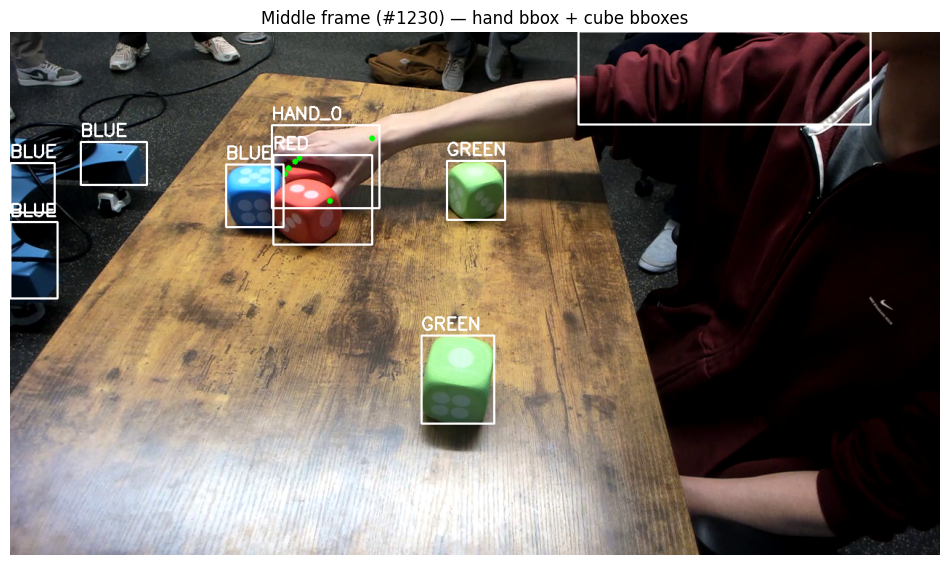

In [ ]:
# --- One-cell script: grab middle frame of first video, detect hand + cubes, draw boxes ---
import cv2, numpy as np, os, math
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import matplotlib.pyplot as plt

# ----- INPUT -----
VIDEO_PATH = videos[0]  # uses your existing videos list; or set a string path
MODEL_PATH = "/content/hand_landmarker.task"

if not os.path.exists(MODEL_PATH):
    import urllib.request
    url = "https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task"
    urllib.request.urlretrieve(url, MODEL_PATH)

# ----- Create detector -----
base_options = python.BaseOptions(model_asset_path=MODEL_PATH)
options = vision.HandLandmarkerOptions(base_options=base_options, num_hands=2)
hand_detector = vision.HandLandmarker.create_from_options(options)

# ----- Grab middle frame -----
cap = cv2.VideoCapture(VIDEO_PATH)
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
mid_idx = max(0, frame_count // 2)

cap.set(cv2.CAP_PROP_POS_FRAMES, mid_idx)
ok, frame_bgr = cap.read()
cap.release()

if not ok or frame_bgr is None:
    raise RuntimeError(f"Could not read middle frame (index {mid_idx}) from: {VIDEO_PATH}")

H, W = frame_bgr.shape[:2]
vis = frame_bgr.copy()

# =========================
# Hand detection + bbox
# =========================
frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame_rgb)
result = hand_detector.detect(mp_image)

if result.hand_landmarks:
    for h_i, hand in enumerate(result.hand_landmarks):
        # landmarks are normalized [0..1]
        xs = [lm.x for lm in hand]
        ys = [lm.y for lm in hand]
        x1, x2 = int(min(xs) * W), int(max(xs) * W)
        y1, y2 = int(min(ys) * H), int(max(ys) * H)

        # pad bbox a bit
        pad = 10
        x1, y1 = max(0, x1 - pad), max(0, y1 - pad)
        x2, y2 = min(W - 1, x2 + pad), min(H - 1, y2 + pad)

        cv2.rectangle(vis, (x1, y1), (x2, y2), (255, 255, 255), 2)
        cv2.putText(vis, f"HAND_{h_i}", (x1, max(0, y1 - 8)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)

        # draw a few key points (wrist + fingertips) for sanity
        key_ids = [0, 4, 8, 12, 16, 20]
        for k in key_ids:
            lm = hand[k]
            cx, cy = int(lm.x * W), int(lm.y * H)
            cv2.circle(vis, (cx, cy), 4, (0, 255, 0), -1)
else:
    cv2.putText(vis, "NO HAND DETECTED", (20, 40),
                cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 0, 255), 3)

# =========================
# Cube detection (HSV color segmentation) + bboxes
# =========================
def hsv_mask(img_bgr, lower, upper):
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv, np.array(lower), np.array(upper))
    mask = cv2.medianBlur(mask, 5)
    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    return mask

def find_blobs(mask, min_area=800):
    cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    blobs = []
    for c in cnts:
        area = cv2.contourArea(c)
        if area < min_area:
            continue
        x, y, w, h = cv2.boundingRect(c)
        blobs.append((x, y, w, h, float(area)))
    blobs.sort(key=lambda t: t[4], reverse=True)
    return blobs

# Tune these if lighting differs (often just S/V mins)
R1 = ((0,   80, 60), (10,  255, 255))
R2 = ((170, 80, 60), (179, 255, 255))
G  = ((35,  60, 60), (85,  255, 255))
B  = ((90,  60, 60), (135, 255, 255))

mask_r = hsv_mask(frame_bgr, *R1) | hsv_mask(frame_bgr, *R2)
mask_g = hsv_mask(frame_bgr, *G)
mask_b = hsv_mask(frame_bgr, *B)

for color, mask in [("RED", mask_r), ("GREEN", mask_g), ("BLUE", mask_b)]:
    blobs = find_blobs(mask, min_area=800)
    for (x, y, w, h, area) in blobs:
        cv2.rectangle(vis, (x, y), (x + w, y + h), (255, 255, 255), 2)
        cv2.putText(vis, f"{color}", (x, max(0, y - 8)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)

# ----- Show result -----
plt.figure(figsize=(12, 7))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title(f"Middle frame (#{mid_idx}) — hand bbox + cube bboxes")
plt.show()

In [ ]:

import pandas as pd
from collections import Counter, defaultdict

# -----------------------------
# 1) Example input (your sample table)
# -----------------------------
events_df = pd.read_csv("events.csv")

def obj_to_color(obj_id: str) -> str:
    # "RED_1" -> "R", "GREEN_2" -> "G", "BLUE_1" -> "B"
    obj_id = obj_id.upper()
    if obj_id.startswith("RED"):
        return "R"
    if obj_id.startswith("GREEN"):
        return "G"
    if obj_id.startswith("BLUE"):
        return "B"
    return "?"

# -----------------------------
# 2) Learn the target placement sequence from RELEASE events
# -----------------------------
release_seq = events_df[events_df["event"].str.upper() == "RELEASE"]["object"].tolist()
learned_seq = [obj_to_color(o) for o in release_seq]

print("Learned placement sequence (from RELEASE order):", learned_seq)
# Example: ['R','G','B','R','G']  (matches your desired Green red blue red green? -> this sample is R,G,B,R,G)

# If you want to enforce the known goal explicitly, set this instead:
# learned_seq = ["G", "R", "B", "R", "G"]

# -----------------------------
# 3) Build an MDP from the learned sequence
# -----------------------------

ACTIONS = ["R", "G", "B"]
N = len(learned_seq)
STATES = list(range(N + 1))  # 0..N
GAMMA = 0.95

def step(s, a):
    """Return (s_next, reward, done)"""
    if s == N:
        return N, 0.0, True

    correct = learned_seq[s]
    if a == correct:
        s2 = s + 1
        done = (s2 == N)
        reward = (10.0 if done else 1.0)  # big reward at goal, small for correct step
        reward -= 0.1  # step cost
        return s2, reward, done
    else:
        # wrong action: stay in same state and pay cost
        return s, -0.5, False

# -----------------------------
# 4) Value Iteration to learn an optimal policy
# -----------------------------
def value_iteration(iterations=200, tol=1e-8):
    V = {s: 0.0 for s in STATES}
    pi = {s: ACTIONS[0] for s in STATES}

    for _ in range(iterations):
        delta = 0.0
        V_new = V.copy()
        for s in STATES:
            if s == N:
                continue
            q_best = -1e18
            a_best = None
            for a in ACTIONS:
                s2, r, done = step(s, a)
                q = r + (0.0 if done else GAMMA * V[s2])
                if q > q_best:
                    q_best = q
                    a_best = a
            V_new[s] = q_best
            pi[s] = a_best
            delta = max(delta, abs(V_new[s] - V[s]))
        V = V_new
        if delta < tol:
            break
    return V, pi

V, pi = value_iteration()
print("\nLearned policy (state k -> action):")
for s in STATES:
    print(f"  k={s}: {pi[s]}")

# -----------------------------
# 5) Demonstrate rollout (what the "robot" would do)
# -----------------------------
def rollout(max_steps=50):
    s = 0
    traj = []
    for t in range(max_steps):
        if s == N:
            break
        a = pi[s]
        s2, r, done = step(s, a)
        traj.append({"step": t, "k": s, "action": a, "reward": r, "k_next": s2})
        s = s2
        if done:
            break
    return pd.DataFrame(traj)

traj_df = rollout()
print("\nRollout:")
display(traj_df)

print("\nFinal placed sequence according to policy:",
      [pi[k] for k in range(N)])



Learned placement sequence (from RELEASE order): ['R', 'G', 'B', 'R', 'G']

Learned policy (state k -> action):
  k=0: R
  k=1: G
  k=2: B
  k=3: R
  k=4: G
  k=5: R

Rollout:


,step,k,action,reward,k_next
0,0,0,R,0.9,1
1,1,1,G,0.9,2
2,2,2,B,0.9,3
3,3,3,R,0.9,4
4,4,4,G,9.9,5



Final placed sequence according to policy: ['R', 'G', 'B', 'R', 'G']


In [ ]:
def print_mdp_diagram(learned_seq):
    N = len(learned_seq)

    print("\n===== MDP STATES =====")
    for k in range(N + 1):
        if k < N:
            prefix = " ".join(learned_seq[:k]) if k > 0 else "∅"
            print(f"s{k}: [{prefix}]")
        else:
            print(f"s{N}: GOAL STATE")

    print("\n===== MDP TRANSITIONS =====")

    for k in range(N):
        correct = learned_seq[k]

        print(f"\nFrom s{k}:")
        print(f"  -- Place_{correct}  / +1 --> s{k+1}")

        for a in ["G","R","B"]:
            if a != correct:
                print(f"  -- Place_{a}  / -1 --> s{k}")

    print("\nFrom s{}: (terminal state)".format(N))
    print("  -- any action --> s{} (reward = 0)".format(N))

    print("\n===== OPTIMAL POLICY =====")
    for k in range(N):
        print(f"π*(s{k}) = Place_{learned_seq[k]}")
    print(f"π*(s{N}) = TERMINATE")


# Example usage:
learned_seq = ["G","R","B","R","G"]  # replace with your learned sequence
print_mdp_diagram(learned_seq)


===== MDP STATES =====
s0: [∅]
s1: [G]
s2: [G R]
s3: [G R B]
s4: [G R B R]
s5: GOAL STATE

===== MDP TRANSITIONS =====

From s0:
  -- Place_G  / +1 --> s1
  -- Place_R  / -1 --> s0
  -- Place_B  / -1 --> s0

From s1:
  -- Place_R  / +1 --> s2
  -- Place_G  / -1 --> s1
  -- Place_B  / -1 --> s1

From s2:
  -- Place_B  / +1 --> s3
  -- Place_G  / -1 --> s2
  -- Place_R  / -1 --> s2

From s3:
  -- Place_R  / +1 --> s4
  -- Place_G  / -1 --> s3
  -- Place_B  / -1 --> s3

From s4:
  -- Place_G  / +1 --> s5
  -- Place_R  / -1 --> s4
  -- Place_B  / -1 --> s4

From s5: (terminal state)
  -- any action --> s5 (reward = 0)

===== OPTIMAL POLICY =====
π*(s0) = Place_G
π*(s1) = Place_R
π*(s2) = Place_B
π*(s3) = Place_R
π*(s4) = Place_G
π*(s5) = TERMINATE
